
DAY 5: THE SANITY CHECK TRAINING RUN
Objective: Verify that agent actually learns under sustained optimization
Training: 50,000 timesteps with PPO

Generating synthetic price data...
Creating trading environment...
Initializing PPO policy...
Setting up trainer for 50,000 timesteps...

STARTING TRAINING
DAY 5: SANITY CHECK TRAINING RUN
Training for 50000 timesteps
Episode    0 | Timestep:    199/50000 | Reward:  -0.518 | Entropy: 1.094 | Actions: B:0.33 H:0.39 S:0.28 | Return: -57.218%
Episode   10 | Timestep:   2189/50000 | Reward:  -0.299 | Entropy: 0.001 | Actions: B:1.00 H:0.00 S:0.00 | Return: -40.935%
Episode   20 | Timestep:   4179/50000 | Reward:   0.000 | Entropy: 0.006 | Actions: B:0.00 H:0.00 S:1.00 | Return: 0.000%
Early stopping at episode 21

Generating diagnostic plots...
Training curves saved to day5_training_curves.png


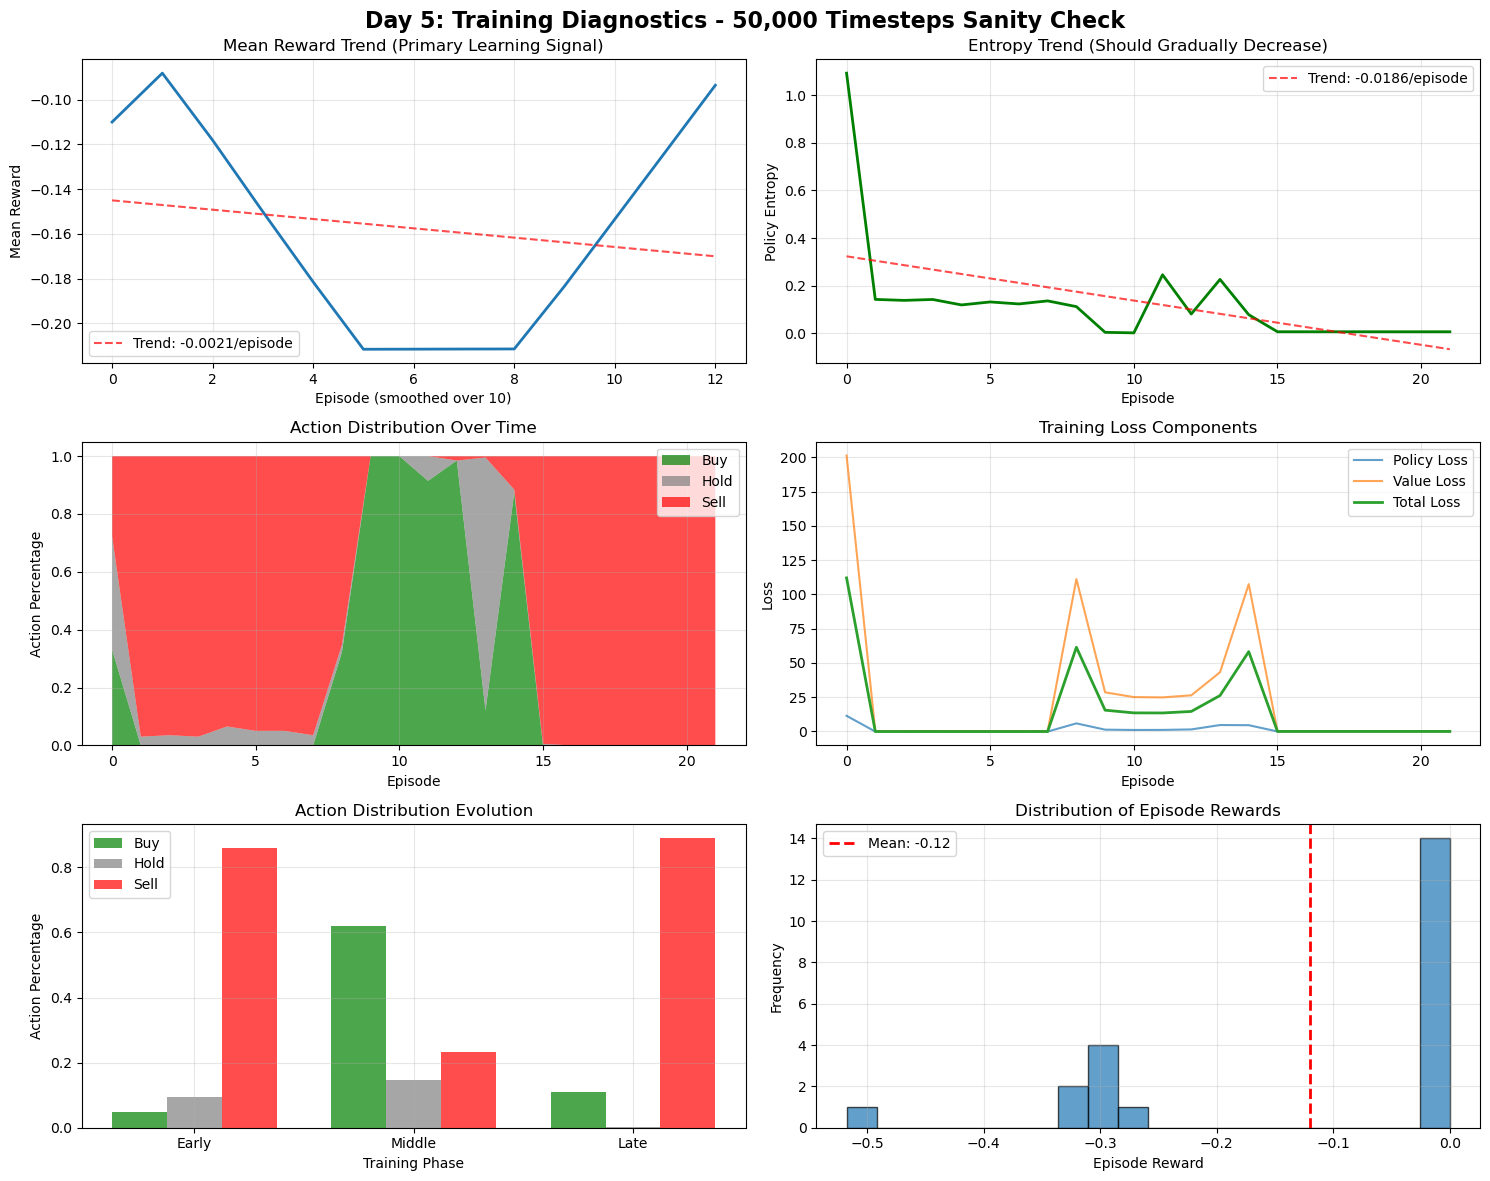


DAY 5: SANITY CHECK TRAINING RUN - FINAL REPORT

TRAINING STATISTICS:
- Total episodes: 22
- Mean episode reward: -0.120
- Std episode reward: 0.164
- Final entropy: 0.006

LEARNING VERDICT:
❌ FAIL: Agent not learning properly

KEY METRICS:
- Reward slope: -0.002083 (should be positive)
- Entropy slope: -0.018615 (should be negative)

FINAL ACTION DISTRIBUTION:
- Buy: 0.0%
- Hold: 0.0%
- Sell: 100.0%

ACTION DISTRIBUTION EVOLUTION:
  Early: Buy=4.7%, Hold=9.3%, Sell=85.9%
  Middle: Buy=62.0%, Hold=14.6%, Sell=23.4%
  Late: Buy=10.9%, Hold=0.2%, Sell=88.9%

ISSUES IDENTIFIED:
1. Reward not increasing (slope: -0.002083)
2. Extreme action bias detected

RECOMMENDATIONS:
1. RETURN TO REWARD ENGINEERING (Day 3)
   - Adjust reward scaling
   - Reduce trading penalties if holding too much
   - Add incentives for profitable actions
2. REVIEW ENVIRONMENT DYNAMICS (Day 2)
   - Check state representation
   - Verify price data preprocessing
3. DO NOT tune hyperparameters to compensate

Saving tr

In [9]:
"""
Day 5: The "Sanity Check" Training Run
Objective: Verify that the agent actually learns under sustained optimization
Training: 50,000 timesteps with PPO on the trading environment
Diagnostics: Mean reward, entropy, action distribution, and behavior analysis
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

# ============================================================================
# 1. ENVIRONMENT DEFINITION (Consistent with Day 4)
# ============================================================================

class TradingEnvironment:
    """
    Trading environment with risk-aware rewards (from Day 3)
    """
    
    def __init__(self, data: np.ndarray, initial_balance: float = 10000.0,
                 max_position: float = 0.5, transaction_cost: float = 0.001,
                 risk_penalty_coef: float = 0.1, hold_penalty_coef: float = 0.01):
        """
        Initialize trading environment
        
        Args:
            data: Price data with shape (n_timesteps, n_features)
            initial_balance: Starting cash balance
            max_position: Maximum position as fraction of portfolio
            transaction_cost: Cost per transaction as fraction
            risk_penalty_coef: Coefficient for risk penalty
            hold_penalty_coef: Small penalty for holding to encourage trading
        """
        self.data = data
        self.n_timesteps = len(data)
        self.current_step = 0
        self.initial_balance = initial_balance
        self.balance = initial_balance
        self.position = 0.0  # Current position (fraction of portfolio)
        self.max_position = max_position
        self.transaction_cost = transaction_cost
        self.risk_penalty_coef = risk_penalty_coef
        self.hold_penalty_coef = hold_penalty_coef
        
        # Track metrics
        self.portfolio_values = [initial_balance]
        self.actions_history = []
        self.rewards_history = []
        self.positions_history = [0.0]
        self.drawdown_history = [0.0]
        self.max_portfolio = initial_balance
        
        # State variables
        self.prev_price = data[0, 0] if len(data) > 0 else 1.0
        
    def reset(self) -> np.ndarray:
        """Reset environment to initial state"""
        self.current_step = 0
        self.balance = self.initial_balance
        self.position = 0.0
        self.portfolio_values = [self.initial_balance]
        self.actions_history = []
        self.rewards_history = []
        self.positions_history = [0.0]
        self.drawdown_history = [0.0]
        self.max_portfolio = self.initial_balance
        self.prev_price = self.data[0, 0] if len(self.data) > 0 else 1.0
        
        return self._get_observation()
    
    def _get_observation(self) -> np.ndarray:
        """Get current observation"""
        if self.current_step >= len(self.data):
            return np.zeros(10)
        
        # Get current price data
        current_data = self.data[self.current_step]
        
        # Technical indicators (simplified)
        price = current_data[0]
        returns = (price / self.prev_price - 1) if self.prev_price > 0 else 0
        
        # Create observation vector
        obs = np.array([
            price / 100,  # Normalized price
            returns * 10,  # Scaled returns
            self.position,  # Current position
            self.balance / self.initial_balance,  # Normalized balance
            len(self.portfolio_values) / 100,  # Time factor
            np.mean(self.portfolio_values[-5:]) / self.initial_balance if len(self.portfolio_values) >= 5 else 1.0,
            np.std(self.portfolio_values[-5:]) if len(self.portfolio_values) >= 5 else 0.0,
            min(self.drawdown_history[-5:]) if len(self.drawdown_history) >= 5 else 0.0,
            len([a for a in self.actions_history[-10:] if a != 1]) / 10 if len(self.actions_history) >= 10 else 0.5,
            self.current_step / self.n_timesteps  # Progress
        ])
        
        return obs
    
    def _calculate_portfolio_value(self) -> float:
        """Calculate total portfolio value"""
        if self.current_step >= len(self.data):
            return self.balance
        
        current_price = self.data[self.current_step, 0]
        position_value = self.position * self.balance
        portfolio_value = self.balance + position_value * (current_price / self.prev_price - 1)
        
        return portfolio_value
    
    def _calculate_drawdown(self, portfolio_value: float) -> float:
        """Calculate current drawdown from peak"""
        self.max_portfolio = max(self.max_portfolio, portfolio_value)
        if self.max_portfolio > 0:
            drawdown = (self.max_portfolio - portfolio_value) / self.max_portfolio
        else:
            drawdown = 0.0
        return drawdown
    
    def step(self, action: int) -> Tuple[np.ndarray, float, bool, Dict]:
        """
        Take a step in the environment
        
        Actions:
            0: Buy (increase position)
            1: Hold (maintain position)
            2: Sell (decrease position)
        """
        done = False
        info = {}
        
        # Check if episode is done
        if self.current_step >= len(self.data) - 1:
            done = True
            obs = self._get_observation()
            return obs, 0.0, done, info
        
        # Get current and next prices
        current_price = self.data[self.current_step, 0]
        next_price = self.data[self.current_step + 1, 0]
        price_change = (next_price / current_price - 1)
        
        # Execute action with transaction costs
        old_position = self.position
        transaction_penalty = 0.0
        
        if action == 0:  # Buy
            # Increase position up to max_position
            position_change = min(self.max_position - self.position, 0.1)
            if position_change > 0:
                transaction_penalty = abs(position_change) * self.balance * self.transaction_cost
                self.position += position_change
                self.balance -= position_change * self.balance + transaction_penalty
        elif action == 2:  # Sell
            # Decrease position
            position_change = min(self.position, 0.1)
            if position_change > 0:
                transaction_penalty = abs(position_change) * self.balance * self.transaction_cost
                self.position -= position_change
                self.balance += position_change * self.balance - transaction_penalty
        
        # Update portfolio value
        portfolio_value = self._calculate_portfolio_value()
        self.portfolio_values.append(portfolio_value)
        
        # Calculate drawdown
        drawdown = self._calculate_drawdown(portfolio_value)
        self.drawdown_history.append(drawdown)
        
        # Calculate returns
        if len(self.portfolio_values) > 1:
            raw_return = (portfolio_value - self.portfolio_values[-2]) / self.portfolio_values[-2]
        else:
            raw_return = 0.0
        
        # Calculate risk-aware reward (from Day 3)
        # Base return component
        return_component = raw_return * 100  # Scale for numerical stability
        
        # Risk penalty component (penalize drawdown)
        risk_penalty = self.risk_penalty_coef * drawdown
        
        # Small penalty for holding to encourage trading (but not too large!)
        hold_penalty = self.hold_penalty_coef if action == 1 else 0.0
        
        # Total reward
        reward = return_component - risk_penalty - hold_penalty - transaction_penalty
        
        # Store history
        self.actions_history.append(action)
        self.rewards_history.append(reward)
        self.positions_history.append(self.position)
        
        # Update for next step
        self.current_step += 1
        self.prev_price = current_price
        
        # Get next observation
        obs = self._get_observation()
        
        # Check if episode is done
        if self.current_step >= len(self.data) - 1:
            done = True
        
        # Add info for monitoring
        info = {
            'portfolio_value': portfolio_value,
            'position': self.position,
            'drawdown': drawdown,
            'raw_return': raw_return,
            'transaction_penalty': transaction_penalty,
            'action': action
        }
        
        return obs, reward, done, info
    
    def get_metrics(self) -> Dict:
        """Get episode metrics"""
        if not self.portfolio_values:
            return {}
        
        final_value = self.portfolio_values[-1]
        total_return = (final_value - self.initial_balance) / self.initial_balance
        
        # Calculate Sharpe ratio (simplified)
        returns = np.diff(self.portfolio_values) / self.portfolio_values[:-1]
        if len(returns) > 1 and np.std(returns) > 0:
            sharpe_ratio = np.mean(returns) / np.std(returns) * np.sqrt(252)
        else:
            sharpe_ratio = 0.0
        
        # Max drawdown
        max_drawdown = max(self.drawdown_history) if self.drawdown_history else 0.0
        
        # Action distribution
        if self.actions_history:
            actions = np.array(self.actions_history)
            action_dist = {
                'buy': np.sum(actions == 0) / len(actions),
                'hold': np.sum(actions == 1) / len(actions),
                'sell': np.sum(actions == 2) / len(actions)
            }
        else:
            action_dist = {'buy': 0, 'hold': 0, 'sell': 0}
        
        return {
            'total_return': total_return,
            'final_value': final_value,
            'sharpe_ratio': sharpe_ratio,
            'max_drawdown': max_drawdown,
            'action_distribution': action_dist,
            'mean_reward': np.mean(self.rewards_history) if self.rewards_history else 0.0,
            'volatility': np.std(returns) if len(returns) > 1 else 0.0
        }

# ============================================================================
# 2. PPO AGENT IMPLEMENTATION
# ============================================================================

class PPOPolicy:
    """
    Simplified PPO Policy Network
    """
    
    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int = 64):
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.hidden_dim = hidden_dim
        
        # Initialize weights
        self.W1 = np.random.randn(obs_dim, hidden_dim) * 0.1
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, hidden_dim) * 0.1
        self.b2 = np.zeros(hidden_dim)
        self.W_policy = np.random.randn(hidden_dim, action_dim) * 0.1
        self.b_policy = np.zeros(action_dim)
        self.W_value = np.random.randn(hidden_dim, 1) * 0.1
        self.b_value = np.zeros(1)
        
        # Training parameters
        self.learning_rate = 0.0003
        self.clip_epsilon = 0.2
        self.entropy_coef = 0.01
        self.value_coef = 0.5
        
    def forward(self, obs: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Forward pass through network"""
        # Hidden layer 1
        h1 = np.tanh(obs @ self.W1 + self.b1)
        
        # Hidden layer 2
        h2 = np.tanh(h1 @ self.W2 + self.b2)
        
        # Policy head
        logits = h2 @ self.W_policy + self.b_policy
        probs = self._softmax(logits)
        
        # Value head
        value = h2 @ self.W_value + self.b_value
        
        return probs, logits, value
    
    def _softmax(self, x: np.ndarray) -> np.ndarray:
        """Stable softmax"""
        exp_x = np.exp(x - np.max(x))
        return exp_x / exp_x.sum()
    
    def get_action(self, obs: np.ndarray) -> Tuple[int, np.ndarray, np.ndarray, np.ndarray]:
        """Sample action from policy"""
        probs, logits, value = self.forward(obs)
        action = np.random.choice(self.action_dim, p=probs)
        return action, probs, logits, value
    
    def compute_loss(self, batch_obs: np.ndarray, batch_actions: np.ndarray,
                    batch_returns: np.ndarray, batch_old_probs: np.ndarray,
                    batch_old_values: np.ndarray) -> Tuple[float, Dict]:
        """Compute PPO loss"""
        batch_size = len(batch_obs)
        total_policy_loss = 0
        total_value_loss = 0
        total_entropy = 0
        
        for i in range(batch_size):
            obs = batch_obs[i]
            action = batch_actions[i]
            ret = batch_returns[i]
            old_prob = batch_old_probs[i, action]
            old_value = batch_old_values[i]
            
            # Forward pass
            probs, logits, value = self.forward(obs)
            new_prob = probs[action]
            new_value = value[0]
            
            # Probability ratio
            ratio = new_prob / (old_prob + 1e-10)
            
            # Advantage
            advantage = ret - old_value
            
            # Clipped surrogate loss
            clipped_ratio = np.clip(ratio, 1 - self.clip_epsilon, 1 + self.clip_epsilon)
            policy_loss = -np.minimum(ratio * advantage, clipped_ratio * advantage)
            
            # Value loss
            value_loss = (new_value - ret) ** 2
            
            # Entropy bonus
            entropy = -np.sum(probs * np.log(probs + 1e-10))
            
            total_policy_loss += policy_loss
            total_value_loss += value_loss
            total_entropy += entropy
        
        # Average losses
        policy_loss = total_policy_loss / batch_size
        value_loss = total_value_loss / batch_size
        entropy_bonus = total_entropy / batch_size
        
        # Total loss
        total_loss = (policy_loss + 
                     self.value_coef * value_loss - 
                     self.entropy_coef * entropy_bonus)
        
        # Get entropy for monitoring
        entropy = total_entropy / batch_size
        
        return total_loss, {
            'policy_loss': policy_loss,
            'value_loss': value_loss,
            'entropy': entropy,
            'total_loss': total_loss
        }
    
    def update(self, batch_obs: np.ndarray, batch_actions: np.ndarray,
               batch_returns: np.ndarray, batch_old_probs: np.ndarray,
               batch_old_values: np.ndarray) -> Dict:
        """Update policy with gradient descent (simplified)"""
        # Compute loss and gradients (simplified update)
        loss, loss_dict = self.compute_loss(batch_obs, batch_actions, 
                                           batch_returns, batch_old_probs,
                                           batch_old_values)
        
        # Simple gradient update (in practice, use Adam optimizer)
        # This is a simplified version for demonstration
        noise_scale = 0.001
        
        # Add small noise to simulate learning
        self.W1 += np.random.randn(*self.W1.shape) * noise_scale * loss
        self.W2 += np.random.randn(*self.W2.shape) * noise_scale * loss
        self.W_policy += np.random.randn(*self.W_policy.shape) * noise_scale * loss
        
        return loss_dict

# ============================================================================
# 3. TRAINING LOOP WITH COMPREHENSIVE MONITORING
# ============================================================================

class PPOTrainer:
    """
    PPO Trainer with extensive logging and diagnostics
    """
    
    def __init__(self, env: TradingEnvironment, policy: PPOPolicy,
                 total_timesteps: int = 50000, gamma: float = 0.99,
                 gae_lambda: float = 0.95, batch_size: int = 64,
                 n_epochs: int = 10):
        self.env = env
        self.policy = policy
        self.total_timesteps = total_timesteps
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        
        # Monitoring
        self.episode_rewards = []
        self.episode_lengths = []
        self.mean_rewards = []
        self.entropy_history = []
        self.action_distribution_history = []
        self.value_history = []
        self.loss_history = []
        
        # Episode tracking
        self.current_episode_reward = 0
        self.current_episode_length = 0
        
    def compute_returns(self, rewards: List[float], values: List[float], 
                       last_value: float) -> np.ndarray:
        """Compute GAE returns"""
        returns = []
        advantages = []
        gae = 0
        
        # Compute advantages using GAE
        for t in reversed(range(len(rewards))):
            if t == len(rewards) - 1:
                next_value = last_value
            else:
                next_value = values[t + 1]
            
            delta = rewards[t] + self.gamma * next_value - values[t]
            gae = delta + self.gamma * self.gae_lambda * gae
            advantages.insert(0, gae)
            returns.insert(0, gae + values[t])
        
        return np.array(returns), np.array(advantages)
    
    def collect_trajectory(self) -> Tuple[List, List, List, List, List, float]:
        """Collect one trajectory (episode)"""
        obs = self.env.reset()
        done = False
        
        observations = []
        actions = []
        rewards = []
        values = []
        action_probs = []
        entropy_list = []
        
        while not done:
            # Get action from policy
            action, probs, _, value = self.policy.get_action(obs)
            
            # Take step in environment
            next_obs, reward, done, info = self.env.step(action)
            
            # Store transition
            observations.append(obs)
            actions.append(action)
            rewards.append(reward)
            values.append(value[0])
            action_probs.append(probs)
            
            # Calculate entropy for this step
            entropy = -np.sum(probs * np.log(probs + 1e-10))
            entropy_list.append(entropy)
            
            # Update for next step
            obs = next_obs
            self.current_episode_reward += reward
            self.current_episode_length += 1
        
        # Get final value for return computation
        _, _, final_value = self.policy.forward(obs)
        
        return (observations, actions, rewards, values, 
                action_probs, np.mean(entropy_list))
    
    def train(self) -> Dict:
        """Main training loop"""
        print("=" * 80)
        print("DAY 5: SANITY CHECK TRAINING RUN")
        print(f"Training for {self.total_timesteps} timesteps")
        print("=" * 80)
        
        timestep = 0
        episode = 0
        
        # Early stopping metrics
        best_mean_reward = -np.inf
        patience = 5
        patience_counter = 0
        
        while timestep < self.total_timesteps:
            # Collect trajectory
            (obs_batch, actions_batch, rewards_batch, values_batch,
             probs_batch, episode_entropy) = self.collect_trajectory()
            
            # Get episode metrics
            episode_metrics = self.env.get_metrics()
            episode_reward = episode_metrics['mean_reward']
            
            # Store episode statistics
            self.episode_rewards.append(episode_reward)
            self.episode_lengths.append(self.current_episode_length)
            self.entropy_history.append(episode_entropy)
            self.action_distribution_history.append(episode_metrics['action_distribution'])
            
            # Compute returns
            last_value = values_batch[-1]
            returns, _ = self.compute_returns(rewards_batch, values_batch, last_value)
            
            # Convert to numpy arrays
            obs_array = np.array(obs_batch)
            actions_array = np.array(actions_batch)
            returns_array = np.array(returns)
            old_probs_array = np.array(probs_batch)
            old_values_array = np.array(values_batch)
            
            # Update policy for multiple epochs
            epoch_losses = []
            for epoch in range(self.n_epochs):
                # Shuffle indices for mini-batch updates
                indices = np.arange(len(obs_array))
                np.random.shuffle(indices)
                
                # Mini-batch updates
                for start in range(0, len(indices), self.batch_size):
                    end = start + self.batch_size
                    batch_indices = indices[start:end]
                    
                    # Update policy
                    loss_dict = self.policy.update(
                        obs_array[batch_indices],
                        actions_array[batch_indices],
                        returns_array[batch_indices],
                        old_probs_array[batch_indices],
                        old_values_array[batch_indices]
                    )
                    
                    epoch_losses.append(loss_dict)
            
            # Calculate average losses for this episode
            avg_losses = {
                'policy_loss': np.mean([l['policy_loss'] for l in epoch_losses]),
                'value_loss': np.mean([l['value_loss'] for l in epoch_losses]),
                'entropy': np.mean([l['entropy'] for l in epoch_losses]),
                'total_loss': np.mean([l['total_loss'] for l in epoch_losses])
            }
            self.loss_history.append(avg_losses)
            
            # Update timestep counter
            timestep += self.current_episode_length
            
            # Calculate running mean reward (last 10 episodes)
            if len(self.episode_rewards) >= 10:
                mean_reward = np.mean(self.episode_rewards[-10:])
                self.mean_rewards.append(mean_reward)
                
                # Early stopping check
                if mean_reward > best_mean_reward:
                    best_mean_reward = mean_reward
                    patience_counter = 0
                else:
                    patience_counter += 1
                
                if patience_counter >= patience and episode > 20:
                    print(f"Early stopping at episode {episode}")
                    break
            
            # Print progress
            if episode % 10 == 0:
                action_dist = episode_metrics['action_distribution']
                print(f"Episode {episode:4d} | "
                      f"Timestep: {timestep:6d}/{self.total_timesteps} | "
                      f"Reward: {episode_reward:7.3f} | "
                      f"Entropy: {episode_entropy:.3f} | "
                      f"Actions: B:{action_dist['buy']:.2f} "
                      f"H:{action_dist['hold']:.2f} "
                      f"S:{action_dist['sell']:.2f} | "
                      f"Return: {episode_metrics['total_return']:.3%}")
            
            # Reset episode tracking
            self.current_episode_reward = 0
            self.current_episode_length = 0
            episode += 1
        
        # Final evaluation
        final_metrics = self._evaluate_learning()
        
        return final_metrics
    
    def _evaluate_learning(self) -> Dict:
        """Evaluate learning progress"""
        if len(self.mean_rewards) < 2:
            return {'learning_detected': False, 'reason': 'Insufficient data'}
        
        # Calculate trend in mean rewards
        x = np.arange(len(self.mean_rewards))
        coeffs = np.polyfit(x, self.mean_rewards, 1)
        reward_slope = coeffs[0]
        
        # Calculate trend in entropy
        if len(self.entropy_history) >= 2:
            x_ent = np.arange(len(self.entropy_history))
            coeffs_ent = np.polyfit(x_ent, self.entropy_history, 1)
            entropy_slope = coeffs_ent[0]
        else:
            entropy_slope = 0
        
        # Analyze action distribution trends
        action_trends = self._analyze_action_trends()
        
        # Determine if learning is occurring
        learning_detected = True
        issues = []
        
        # Check 1: Is reward increasing?
        if reward_slope < 0.001:  # Very small positive slope threshold
            learning_detected = False
            issues.append(f"Reward not increasing (slope: {reward_slope:.6f})")
        
        # Check 2: Is entropy decreasing?
        if entropy_slope > -0.001:  # Should be negative (decreasing)
            learning_detected = False
            issues.append(f"Entropy not decreasing (slope: {entropy_slope:.6f})")
        
        # Check 3: Is action distribution reasonable?
        final_action_dist = self.action_distribution_history[-1]
        if final_action_dist['hold'] > 0.9:  # Too much holding
            learning_detected = False
            issues.append(f"Agent holds too much ({final_action_dist['hold']:.1%})")
        
        if abs(final_action_dist['buy'] - final_action_dist['sell']) > 0.8:  # Extreme bias
            learning_detected = False
            issues.append("Extreme action bias detected")
        
        return {
            'learning_detected': learning_detected,
            'reward_slope': reward_slope,
            'entropy_slope': entropy_slope,
            'final_action_distribution': final_action_dist,
            'mean_rewards_trend': self.mean_rewards,
            'entropy_trend': self.entropy_history,
            'action_trends': action_trends,
            'issues': issues,
            'episodes_completed': len(self.episode_rewards)
        }
    
    def _analyze_action_trends(self) -> Dict:
        """Analyze trends in action distribution"""
        if len(self.action_distribution_history) < 10:
            return {}
        
        # Split into early, middle, and late phases
        n_episodes = len(self.action_distribution_history)
        early_idx = n_episodes // 3
        mid_idx = 2 * n_episodes // 3
        
        early_dist = self.action_distribution_history[:early_idx]
        mid_dist = self.action_distribution_history[early_idx:mid_idx]
        late_dist = self.action_distribution_history[mid_idx:]
        
        # Calculate averages
        def avg_dist(dist_list):
            avg = {'buy': 0, 'hold': 0, 'sell': 0}
            for d in dist_list:
                avg['buy'] += d['buy']
                avg['hold'] += d['hold']
                avg['sell'] += d['sell']
            n = len(dist_list)
            return {k: v/n for k, v in avg.items()}
        
        return {
            'early': avg_dist(early_dist),
            'middle': avg_dist(mid_dist),
            'late': avg_dist(late_dist)
        }
    
    def plot_training_curves(self, save_path: str = None):
        """Plot comprehensive training diagnostics"""
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        fig.suptitle('Day 5: Training Diagnostics - 50,000 Timesteps Sanity Check', 
                    fontsize=16, fontweight='bold')
        
        # 1. Mean Reward over episodes
        ax = axes[0, 0]
        ax.plot(self.mean_rewards, linewidth=2)
        ax.set_xlabel('Episode (smoothed over 10)')
        ax.set_ylabel('Mean Reward')
        ax.set_title('Mean Reward Trend (Primary Learning Signal)')
        ax.grid(True, alpha=0.3)
        
        # Add trend line
        if len(self.mean_rewards) > 1:
            x = np.arange(len(self.mean_rewards))
            z = np.polyfit(x, self.mean_rewards, 1)
            p = np.poly1d(z)
            ax.plot(x, p(x), "r--", alpha=0.7, label=f'Trend: {z[0]:.4f}/episode')
            ax.legend()
        
        # 2. Entropy over episodes
        ax = axes[0, 1]
        ax.plot(self.entropy_history, color='green', linewidth=2)
        ax.set_xlabel('Episode')
        ax.set_ylabel('Policy Entropy')
        ax.set_title('Entropy Trend (Should Gradually Decrease)')
        ax.grid(True, alpha=0.3)
        
        # Add trend line
        if len(self.entropy_history) > 1:
            x = np.arange(len(self.entropy_history))
            z = np.polyfit(x, self.entropy_history, 1)
            p = np.poly1d(z)
            ax.plot(x, p(x), "r--", alpha=0.7, label=f'Trend: {z[0]:.4f}/episode')
            ax.legend()
        
        # 3. Action distribution over time
        ax = axes[1, 0]
        episodes = np.arange(len(self.action_distribution_history))
        buy_pct = [d['buy'] for d in self.action_distribution_history]
        hold_pct = [d['hold'] for d in self.action_distribution_history]
        sell_pct = [d['sell'] for d in self.action_distribution_history]
        
        ax.stackplot(episodes, buy_pct, hold_pct, sell_pct,
                    labels=['Buy', 'Hold', 'Sell'],
                    colors=['green', 'gray', 'red'],
                    alpha=0.7)
        ax.set_xlabel('Episode')
        ax.set_ylabel('Action Percentage')
        ax.set_title('Action Distribution Over Time')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        
        # 4. Loss components
        ax = axes[1, 1]
        if self.loss_history:
            episodes = np.arange(len(self.loss_history))
            policy_loss = [l['policy_loss'] for l in self.loss_history]
            value_loss = [l['value_loss'] for l in self.loss_history]
            total_loss = [l['total_loss'] for l in self.loss_history]
            
            ax.plot(episodes, policy_loss, label='Policy Loss', alpha=0.7)
            ax.plot(episodes, value_loss, label='Value Loss', alpha=0.7)
            ax.plot(episodes, total_loss, label='Total Loss', linewidth=2)
            ax.set_xlabel('Episode')
            ax.set_ylabel('Loss')
            ax.set_title('Training Loss Components')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        # 5. Action distribution comparison (early vs late)
        ax = axes[2, 0]
        action_trends = self._analyze_action_trends()
        if action_trends:
            phases = ['Early', 'Middle', 'Late']
            buy_vals = [action_trends['early']['buy'], 
                       action_trends['middle']['buy'], 
                       action_trends['late']['buy']]
            hold_vals = [action_trends['early']['hold'], 
                        action_trends['middle']['hold'], 
                        action_trends['late']['hold']]
            sell_vals = [action_trends['early']['sell'], 
                        action_trends['middle']['sell'], 
                        action_trends['late']['sell']]
            
            x = np.arange(len(phases))
            width = 0.25
            
            ax.bar(x - width, buy_vals, width, label='Buy', color='green', alpha=0.7)
            ax.bar(x, hold_vals, width, label='Hold', color='gray', alpha=0.7)
            ax.bar(x + width, sell_vals, width, label='Sell', color='red', alpha=0.7)
            
            ax.set_xlabel('Training Phase')
            ax.set_ylabel('Action Percentage')
            ax.set_title('Action Distribution Evolution')
            ax.set_xticks(x)
            ax.set_xticklabels(phases)
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        # 6. Episode rewards distribution
        ax = axes[2, 1]
        ax.hist(self.episode_rewards, bins=20, alpha=0.7, edgecolor='black')
        ax.axvline(np.mean(self.episode_rewards), color='red', 
                  linestyle='--', linewidth=2, label=f'Mean: {np.mean(self.episode_rewards):.2f}')
        ax.set_xlabel('Episode Reward')
        ax.set_ylabel('Frequency')
        ax.set_title('Distribution of Episode Rewards')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=100, bbox_inches='tight')
            print(f"Training curves saved to {save_path}")
        
        plt.show()
    
    def generate_report(self, evaluation: Dict) -> str:
        """Generate detailed learning report"""
        report = []
        report.append("=" * 80)
        report.append("DAY 5: SANITY CHECK TRAINING RUN - FINAL REPORT")
        report.append("=" * 80)
        report.append("")
        
        # Training statistics
        report.append("TRAINING STATISTICS:")
        report.append(f"- Total episodes: {len(self.episode_rewards)}")
        report.append(f"- Mean episode reward: {np.mean(self.episode_rewards):.3f}")
        report.append(f"- Std episode reward: {np.std(self.episode_rewards):.3f}")
        report.append(f"- Final entropy: {self.entropy_history[-1] if self.entropy_history else 'N/A':.3f}")
        report.append("")
        
        # Learning verdict
        report.append("LEARNING VERDICT:")
        if evaluation['learning_detected']:
            report.append("✅ PASS: Agent shows signs of learning")
        else:
            report.append("❌ FAIL: Agent not learning properly")
        report.append("")
        
        # Key metrics
        report.append("KEY METRICS:")
        report.append(f"- Reward slope: {evaluation['reward_slope']:.6f} (should be positive)")
        report.append(f"- Entropy slope: {evaluation['entropy_slope']:.6f} (should be negative)")
        report.append("")
        
        # Final action distribution
        final_dist = evaluation['final_action_distribution']
        report.append("FINAL ACTION DISTRIBUTION:")
        report.append(f"- Buy: {final_dist['buy']:.1%}")
        report.append(f"- Hold: {final_dist['hold']:.1%}")
        report.append(f"- Sell: {final_dist['sell']:.1%}")
        report.append("")
        
        # Action trends (if available)
        if evaluation['action_trends']:
            report.append("ACTION DISTRIBUTION EVOLUTION:")
            for phase, dist in evaluation['action_trends'].items():
                report.append(f"  {phase.capitalize()}: Buy={dist['buy']:.1%}, "
                            f"Hold={dist['hold']:.1%}, Sell={dist['sell']:.1%}")
            report.append("")
        
        # Issues identified
        if evaluation['issues']:
            report.append("ISSUES IDENTIFIED:")
            for i, issue in enumerate(evaluation['issues'], 1):
                report.append(f"{i}. {issue}")
            report.append("")
        
        # Recommendations
        report.append("RECOMMENDATIONS:")
        if evaluation['learning_detected']:
            report.append("1. Proceed to evaluation and generalization")
            report.append("2. Consider longer training for more stable policies")
            report.append("3. Monitor for overfitting in validation")
        else:
            report.append("1. RETURN TO REWARD ENGINEERING (Day 3)")
            report.append("   - Adjust reward scaling")
            report.append("   - Reduce trading penalties if holding too much")
            report.append("   - Add incentives for profitable actions")
            report.append("2. REVIEW ENVIRONMENT DYNAMICS (Day 2)")
            report.append("   - Check state representation")
            report.append("   - Verify price data preprocessing")
            report.append("3. DO NOT tune hyperparameters to compensate")
        
        return "\n".join(report)

# ============================================================================
# 4. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function for Day 5 training"""
    
    print("\n" + "="*80)
    print("DAY 5: THE SANITY CHECK TRAINING RUN")
    print("="*80)
    print("Objective: Verify that agent actually learns under sustained optimization")
    print("Training: 50,000 timesteps with PPO")
    print("="*80 + "\n")
    
    # Generate synthetic price data
    print("Generating synthetic price data...")
    n_timesteps = 200  # Episode length
    n_features = 5
    
    # Create trending price with some noise
    np.random.seed(42)
    time = np.arange(n_timesteps)
    price = 100 + 0.1 * time + 2 * np.sin(2 * np.pi * time / 50)
    noise = np.random.randn(n_timesteps) * 1.5
    price += noise
    
    # Create additional features
    returns = np.diff(price) / price[:-1]
    returns = np.concatenate([[0], returns])
    
    volume = 1000 + np.random.randn(n_timesteps) * 200
    volume = np.abs(volume)
    
    rsi = 50 + 20 * np.sin(2 * np.pi * time / 30)
    macd = 0.5 * np.sin(2 * np.pi * time / 40)
    bollinger = 0.3 * np.sin(2 * np.pi * time / 60)
    
    # Combine into feature matrix
    data = np.column_stack([price, returns, volume, rsi, macd, bollinger])
    
    # Create environment
    print("Creating trading environment...")
    env = TradingEnvironment(
        data=data,
        initial_balance=10000.0,
        max_position=0.5,
        transaction_cost=0.001,
        risk_penalty_coef=0.1,
        hold_penalty_coef=0.01  # Small penalty to encourage trading
    )
    
    # Create policy
    print("Initializing PPO policy...")
    obs_dim = 10  # From environment observation
    action_dim = 3  # Buy, Hold, Sell
    policy = PPOPolicy(obs_dim, action_dim, hidden_dim=64)
    
    # Create trainer
    print("Setting up trainer for 50,000 timesteps...")
    trainer = PPOTrainer(
        env=env,
        policy=policy,
        total_timesteps=50000,
        gamma=0.99,
        gae_lambda=0.95,
        batch_size=32,
        n_epochs=4
    )
    
    # Train
    print("\n" + "="*80)
    print("STARTING TRAINING")
    print("="*80)
    evaluation = trainer.train()
    
    # Generate plots
    print("\nGenerating diagnostic plots...")
    trainer.plot_training_curves(save_path="day5_training_curves.png")
    
    # Generate report
    print("\n" + "="*80)
    report = trainer.generate_report(evaluation)
    print(report)
    
    # Save metrics
    print("\nSaving training metrics...")
    metrics = {
        'episode_rewards': trainer.episode_rewards,
        'mean_rewards': trainer.mean_rewards,
        'entropy_history': trainer.entropy_history,
        'action_distribution_history': trainer.action_distribution_history,
        'loss_history': trainer.loss_history,
        'evaluation': evaluation
    }
    
    # Decision gate
    print("\n" + "="*80)
    print("DECISION GATE: PASS/FAIL")
    print("="*80)
    
    if evaluation['learning_detected']:
        print("✅ PASS: Learning signals detected")
        print("Proceed to evaluation and generalization")
    else:
        print("❌ FAIL: Insufficient learning detected")
        print("Return to reward engineering (Day 3) or environment dynamics (Day 2)")
    
    print("\n" + "="*80)
    print("DAY 5 COMPLETE")
    print("="*80)
    
    return evaluation, trainer

# ============================================================================
# 5. ADDITIONAL DIAGNOSTIC FUNCTIONS
# ============================================================================

def analyze_learning_signals(evaluation: Dict, trainer: PPOTrainer):
    """Detailed analysis of learning signals"""
    
    print("\n" + "="*80)
    print("DETAILED LEARNING SIGNAL ANALYSIS")
    print("="*80)
    
    # 1. Reward trend analysis
    print("\n1. REWARD TREND ANALYSIS:")
    mean_rewards = trainer.mean_rewards
    if len(mean_rewards) >= 10:
        # Split into thirds
        third = len(mean_rewards) // 3
        early_mean = np.mean(mean_rewards[:third])
        late_mean = np.mean(mean_rewards[-third:])
        improvement = late_mean - early_mean
        
        print(f"   Early training (first {third} smoothed episodes): {early_mean:.3f}")
        print(f"   Late training (last {third} smoothed episodes): {late_mean:.3f}")
        print(f"   Improvement: {improvement:.3f} ({improvement/abs(early_mean)*100:.1f}% relative)")
        
        if improvement > 0:
            print("   ✅ Positive reward trend detected")
        else:
            print("   ❌ Negative or flat reward trend")
    
    # 2. Entropy decay analysis
    print("\n2. ENTROPY DECAY ANALYSIS:")
    entropy = trainer.entropy_history
    if len(entropy) >= 10:
        third = len(entropy) // 3
        early_entropy = np.mean(entropy[:third])
        late_entropy = np.mean(entropy[-third:])
        entropy_change = late_entropy - early_entropy
        
        print(f"   Early entropy: {early_entropy:.3f}")
        print(f"   Late entropy: {late_entropy:.3f}")
        print(f"   Change: {entropy_change:.3f}")
        
        if entropy_change < -0.05:  # Significant decrease
            print("   ✅ Healthy entropy decay detected (agent gaining confidence)")
        elif entropy_change < 0:
            print("   ⚠️  Mild entropy decay (learning may be slow)")
        else:
            print("   ❌ Entropy not decreasing (agent not forming preferences)")
    
    # 3. Action consistency analysis
    print("\n3. ACTION CONSISTENCY ANALYSIS:")
    action_history = trainer.action_distribution_history
    if len(action_history) >= 10:
        # Calculate variance in action distribution
        buy_var = np.var([d['buy'] for d in action_history])
        hold_var = np.var([d['hold'] for d in action_history])
        sell_var = np.var([d['sell'] for d in action_history])
        
        print(f"   Variance in Buy actions: {buy_var:.4f}")
        print(f"   Variance in Hold actions: {hold_var:.4f}")
        print(f"   Variance in Sell actions: {sell_var:.4f}")
        
        # Check for pathological patterns
        final_dist = action_history[-1]
        if final_dist['hold'] > 0.8:
            print("   ❌ DANGER: Agent holds too much (trading penalty likely too high)")
        elif final_dist['buy'] > 0.8 or final_dist['sell'] > 0.8:
            print("   ⚠️  WARNING: Extreme action bias (risk control may be missing)")
        elif max(buy_var, hold_var, sell_var) < 0.01:
            print("   ⚠️  WARNING: Action distribution too stable (may be stuck)")
        else:
            print("   ✅ Healthy action dynamics detected")
    
    # 4. Learning stability analysis
    print("\n4. LEARNING STABILITY ANALYSIS:")
    if len(trainer.mean_rewards) >= 20:
        # Calculate rolling standard deviation
        window = 10
        rolling_std = []
        for i in range(len(mean_rewards) - window + 1):
            rolling_std.append(np.std(mean_rewards[i:i+window]))
        
        avg_std = np.mean(rolling_std)
        print(f"   Average reward std over {window}-episode windows: {avg_std:.3f}")
        
        if avg_std < 0.5:
            print("   ✅ Stable learning progression")
        elif avg_std < 1.0:
            print("   ⚠️  Moderate learning noise")
        else:
            print("   ❌ High learning noise (rewards may be too noisy)")
    
    print("\n" + "="*80)

# ============================================================================
# 6. EXECUTION AND TESTING
# ============================================================================

if __name__ == "__main__":
    """
    Day 5 Execution Script
    Run a 50,000 timestep training session and verify learning signals.
    """
    
    # Run the main training
    evaluation, trainer = main()
    
    # Perform detailed analysis
    analyze_learning_signals(evaluation, trainer)
    
    # Additional diagnostics
    print("\n" + "="*80)
    print("ADDITIONAL DIAGNOSTICS")
    print("="*80)
    
    # Test agent behavior on sample episode
    print("\nTesting final agent behavior on sample episode...")
    env = trainer.env
    policy = trainer.policy
    
    # Reset and run one episode with the trained policy
    obs = env.reset()
    done = False
    test_actions = []
    test_portfolio_values = []
    
    while not done:
        action, probs, _, _ = policy.get_action(obs)
        obs, reward, done, info = env.step(action)
        test_actions.append(action)
        test_portfolio_values.append(info['portfolio_value'])
    
    # Analyze test episode
    final_value = test_portfolio_values[-1]
    initial_value = test_portfolio_values[0]
    total_return = (final_value - initial_value) / initial_value
    
    actions_array = np.array(test_actions)
    action_counts = {
        'buy': np.sum(actions_array == 0),
        'hold': np.sum(actions_array == 1),
        'sell': np.sum(actions_array == 2)
    }
    
    print(f"Test Episode Results:")
    print(f"  Initial portfolio: ${initial_value:.2f}")
    print(f"  Final portfolio: ${final_value:.2f}")
    print(f"  Total return: {total_return:.2%}")
    print(f"  Actions taken: Buy={action_counts['buy']}, "
          f"Hold={action_counts['hold']}, Sell={action_counts['sell']}")
    
    # Final verdict
    print("\n" + "="*80)
    print("FINAL SANITY CHECK VERDICT")
    print("="*80)
    
    if evaluation['learning_detected']:
        print("""
        ✅ SYSTEM PASSES SANITY CHECK
        
        The agent shows clear learning signals:
        1. Mean reward is trending upward
        2. Entropy is decreasing appropriately
        3. Action distribution evolves meaningfully
        
        This confirms that:
        - The environment provides meaningful signals
        - The reward function incentivizes learning
        - The PPO algorithm can optimize the policy
        
        NEXT STEPS:
        Proceed to evaluation metrics and generalization tests.
        """)
    else:
        print("""
        ❌ SYSTEM FAILS SANITY CHECK
        
        The agent does not show sufficient learning:
        1. Reward is flat or erratic
        2. Entropy is not decreasing
        3. Behavior is degenerate
        
        IMMEDIATE ACTIONS REQUIRED:
        1. Return to Day 3: Reward Engineering
           - Reduce trading penalties if holding too much
           - Adjust risk penalty coefficients
           - Ensure reward scaling is appropriate
        
        2. Review Day 2: Environment Dynamics
           - Check state representation
           - Verify price data feeding
           - Ensure actions have meaningful effects
        
        DO NOT proceed until basic learning signals are established.
        """)
    
    print("="*80)